


# ============================================================
# MODEL / EXPERIMENT CONFIGURATION
Final 2 hours Model
# ============================================================
resample_freq = 1h"

train_ratio = 0.70

val_ratio = 0.15

test_ratio = 0.15

target_col = "scd41_co2"

history_days = 7

forecast_hours = 2

batch_size = 64

num_epochs = 15

d_model=32

nhead=4,

num_layers=1,

dim_feedforward=64,

dropout=0.2

lr=0.0003




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../../data/indoorAir2.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")

# Sort by station and time
df = df.sort_values(by='timestamp')

print(df.shape)
df.head()

(1924653, 21)


,id,station_id,station_name,timestamp,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,...,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
0,1,1,station_room_233,2024-11-13 16:57:56,488.0,22.951857,36.897277,418,32,1,...,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,station_room_233,2024-11-13 16:58:57,485.0,22.335011,38.185119,414,30,1,...,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,station_room_233,2024-11-13 16:59:59,477.0,22.353704,38.400268,443,43,1,...,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,station_room_233,2024-11-13 17:01:03,474.0,22.417792,38.269042,406,26,1,...,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,station_room_233,2024-11-13 17:02:05,473.0,22.556649,37.971496,416,31,1,...,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Remove Station id 6
df = df[df["station_id"] != 6].copy()

feature_df = df[
    [
        "ens160_aqi",
        "ens160_tvoc",
        "bme688_gas_resistance",
        "bme688_pressure",
        "scd41_temperature",
        "scd41_humidity",
        "timestamp",
        "scd41_co2",
        "station_id",
    ]
].copy()

resample_freq = "1h"

value_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
]

feature_df["timestamp"] = pd.to_datetime(feature_df["timestamp"])

feature_df = (
    feature_df
    .sort_values(["station_id", "timestamp"])
    .set_index("timestamp")
    .groupby("station_id")[value_cols]
    .resample(resample_freq)
    .mean()
    .reset_index()
)

feature_df[value_cols] = (
    feature_df
    .groupby("station_id")[value_cols]
    .transform(lambda x: x.interpolate(method="linear").ffill().bfill())
)

feature_df["hour"] = feature_df["timestamp"].dt.hour + feature_df["timestamp"].dt.minute / 60
feature_df["dayofweek"] = feature_df["timestamp"].dt.dayofweek

feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df["hour"] / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df["hour"] / 24)

feature_df["dayofweek_sin"] = np.sin(2 * np.pi * feature_df["dayofweek"] / 7)
feature_df["dayofweek_cos"] = np.cos(2 * np.pi * feature_df["dayofweek"] / 7)

feature_df["is_weekend"] = feature_df["dayofweek"].isin([5, 6]).astype(int)

feature_df = feature_df.drop(columns=["hour", "dayofweek"])

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

print(feature_df.shape)
feature_df.head()

(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [5]:
feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

gap_check = (
    feature_df
    .assign(
        next_timestamp=feature_df.groupby("station_id")["timestamp"].shift(-1)
    )
)

gap_check["next_gap"] = gap_check["next_timestamp"] - gap_check["timestamp"]

print(gap_check["next_gap"].value_counts(dropna=False).head(10))
print(feature_df.shape)

feature_df.head()

next_gap
0 days 01:00:00    46723
NaT                    5
Name: count, dtype: int64
(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [6]:
cols_to_fill = ["bme688_gas_resistance", "bme688_pressure"]

feature_df = feature_df.sort_values(["station_id", "timestamp"]).reset_index(drop=True)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .transform(lambda x: x.interpolate(method="linear"))
)

feature_df[cols_to_fill] = (
    feature_df
    .groupby("station_id")[cols_to_fill]
    .ffill()
    .bfill()
)

print(feature_df.shape)
feature_df.head()

(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [7]:
numeric_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

outlier_bounds = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).sum(),
        "outlier_percent_before": ((feature_df[col] < lower) | (feature_df[col] > upper)).mean() * 100
    }

    feature_df[col] = feature_df[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_bounds).T
print(outlier_df)
print(feature_df.shape)
feature_df.head()

                        lower_bound   upper_bound  outlier_count_before  \
ens160_aqi            -5.000000e-01  3.500000e+00                 239.0   
ens160_tvoc           -1.001371e+02  2.916415e+02                4518.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07                   0.0   
bme688_pressure        9.848833e+01  1.018886e+02                1746.0   
scd41_temperature      1.968881e+01  2.915764e+01                 754.0   
scd41_humidity         9.268762e+00  6.307558e+01                  24.0   
scd41_co2              2.498759e+02  7.461140e+02                4962.0   

                       outlier_percent_before  
ens160_aqi                           0.511471  
ens160_tvoc                          9.668721  
bme688_gas_resistance                0.000000  
bme688_pressure                      3.736518  
scd41_temperature                    1.613594  
scd41_humidity                       0.051361  
scd41_co2                           10.618901  
(46728, 14)


,station_id,timestamp,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend
0,1,2024-11-13 16:00:00,1.0,35.000000,12946860.0,100.558889,22.546857,37.827555,483.333333,-0.866025,-5.000000e-01,0.974928,-0.222521,0
1,1,2024-11-13 17:00:00,1.0,26.857143,12946860.0,100.558889,22.746242,37.604195,472.285714,-0.965926,-2.588190e-01,0.974928,-0.222521,0
2,1,2024-11-13 18:00:00,1.0,26.836996,12946860.0,100.558889,22.800984,37.733780,471.120879,-1.000000,-1.836970e-16,0.974928,-0.222521,0
3,1,2024-11-13 19:00:00,1.0,26.816850,12946860.0,100.558889,22.855726,37.863365,469.956044,-0.965926,2.588190e-01,0.974928,-0.222521,0
4,1,2024-11-13 20:00:00,1.0,26.796703,12946860.0,100.558889,22.910467,37.992950,468.791209,-0.866025,5.000000e-01,0.974928,-0.222521,0


In [8]:
outlier_summary = {}

for col in numeric_cols:
    Q1 = feature_df[col].quantile(0.25)
    Q3 = feature_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((feature_df[col] < lower) | (feature_df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (outlier_count / len(feature_df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

                        lower_bound   upper_bound  outlier_count  \
ens160_aqi            -5.000000e-01  3.500000e+00            0.0   
ens160_tvoc           -1.001371e+02  2.916415e+02            0.0   
bme688_gas_resistance  1.287263e+07  1.299140e+07            0.0   
bme688_pressure        9.848833e+01  1.018886e+02            0.0   
scd41_temperature      1.968881e+01  2.915764e+01            0.0   
scd41_humidity         9.268762e+00  6.307558e+01            0.0   
scd41_co2              2.498759e+02  7.461140e+02            0.0   

                       outlier_percent  
ens160_aqi                         0.0  
ens160_tvoc                        0.0  
bme688_gas_resistance              0.0  
bme688_pressure                    0.0  
scd41_temperature                  0.0  
scd41_humidity                     0.0  
scd41_co2                          0.0  


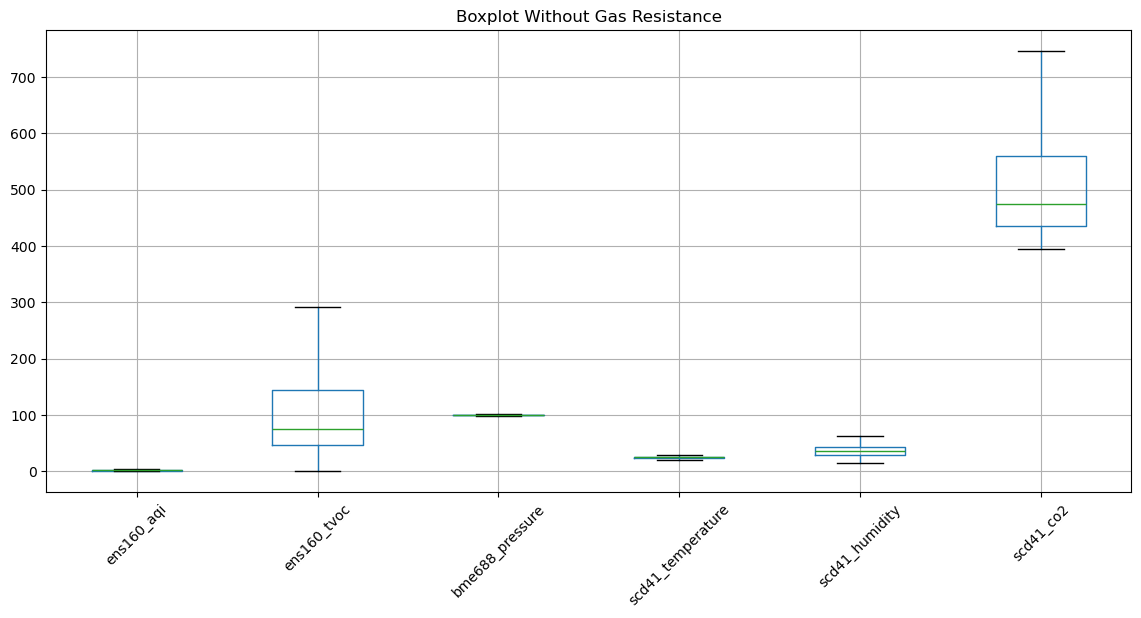

In [9]:
plot_cols = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2"
]

feature_df[plot_cols].boxplot(figsize=(14, 6), rot=45)
plt.title("Boxplot Without Gas Resistance")
plt.show()

In [10]:
# ==========================================
# Step 8 - Time-Based Split
# ==========================================

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

def split_station_data(station_data):
    station_data = station_data.sort_values("timestamp")
    n_rows = len(station_data)
    train_end = int(n_rows * train_ratio)
    val_end = train_end + int(n_rows * val_ratio)

    return (
        station_data.iloc[:train_end],
        station_data.iloc[train_end:val_end],
        station_data.iloc[val_end:],
    )

train_parts = []
val_parts = []
test_parts = []

for station_id, station_data in feature_df.groupby("station_id", sort=True):
    station_train, station_val, station_test = split_station_data(station_data)
    train_parts.append(station_train)
    val_parts.append(station_val)
    test_parts.append(station_test)

train_df = pd.concat(train_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
val_df = pd.concat(val_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)
test_df = pd.concat(test_parts).sort_values(["station_id", "timestamp"]).reset_index(drop=True)

total_rows = len(feature_df)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train percentage:", len(train_df) / total_rows * 100)
print("Val percentage:", len(val_df) / total_rows * 100)
print("Test percentage:", len(test_df) / total_rows * 100)

split_counts = pd.concat(
    [
        train_df.groupby("station_id").size().rename("train"),
        val_df.groupby("station_id").size().rename("val"),
        test_df.groupby("station_id").size().rename("test"),
    ],
    axis=1,
).fillna(0).astype(int)

print("\nRows per station:")
print(split_counts)

Train shape: (32707, 14)
Val shape: (7007, 14)
Test shape: (7014, 14)
Train percentage: 69.9944358842664
Val percentage: 14.995291902071564
Test percentage: 15.010272213662043

Rows per station:
            train   val  test
station_id                   
1            8818  1889  1891
2            3392   726   728
3            7729  1656  1657
4            7657  1641  1642
5            5111  1095  1096


In [11]:
target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col not in ["timestamp"]
]

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = x_scaler.fit_transform(train_df[feature_cols])
val_df_scaled[feature_cols] = x_scaler.transform(val_df[feature_cols])
test_df_scaled[feature_cols] = x_scaler.transform(test_df[feature_cols])

train_df_scaled[[target_col]] = y_scaler.fit_transform(train_df[[target_col]])
val_df_scaled[[target_col]] = y_scaler.transform(val_df[[target_col]])
test_df_scaled[[target_col]] = y_scaler.transform(test_df[[target_col]])

print("Input features:", feature_cols)
print("Past CO2 included:", target_col in feature_cols)
print("Scaled X train min/max:", train_df_scaled[feature_cols].min().min(), train_df_scaled[feature_cols].max().max())
print("Scaled y train min/max:", train_df_scaled[target_col].min(), train_df_scaled[target_col].max())

Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
Past CO2 included: True
Scaled X train min/max: 0.0 1.0
Scaled y train min/max: 0.0 1.0


In [12]:
history_days = 7
forecast_hours = 2

samples_per_hour = int(pd.Timedelta(hours=1) / pd.Timedelta(resample_freq))

input_size = history_days * 24 * samples_per_hour          # 7 days = 672 rows at 15 min
forecast_horizon_steps = forecast_hours * samples_per_hour # 2 hours = 8 rows at 15 min

target_col = "scd41_co2"

feature_cols = [
    col for col in feature_df.columns
    if col != "timestamp"
]

print(f"History window: {input_size} rows = {history_days} days")
print(f"Forecast horizon: {forecast_horizon_steps} rows = {forecast_hours} hours ahead")
print("Input features:", feature_cols)

def create_windows(data, feature_cols, target_col):
    X_windows = []
    y_windows = []

    data = data.sort_values(["station_id", "timestamp"])

    for station_id, station_data in data.groupby("station_id"):
        X = station_data[feature_cols].values.astype("float32")
        y = station_data[target_col].values.astype("float32")

        # Input: previous 7 days
        # Target: CO2 exactly 2 hours after the last input timestamp
        max_start = len(station_data) - forecast_horizon_steps + 1

        for i in range(input_size, max_start):
            target_idx = i + forecast_horizon_steps - 1

            X_windows.append(X[i - input_size:i])
            y_windows.append(y[target_idx])

    return np.array(X_windows, dtype="float32"), np.array(y_windows, dtype="float32")


X_train, y_train = create_windows(train_df_scaled, feature_cols, target_col)
X_val, y_val = create_windows(val_df_scaled, feature_cols, target_col)
X_test, y_test = create_windows(test_df_scaled, feature_cols, target_col)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

History window: 168 rows = 7 days
Forecast horizon: 2 rows = 2 hours ahead
Input features: ['station_id', 'ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']
X_train: (31862, 168, 13) y_train: (31862,)
X_val: (6162, 168, 13) y_val: (6162,)
X_test: (6169, 168, 13) y_test: (6169,)


In [13]:
batch_size = 64

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 498
Val batches: 97
Test batches: 97


In [14]:
import math
import torch
import torch.nn as nn


class TransformerRegressor(nn.Module):
    def __init__(
        self,
        num_features,
        d_model=32,
        nhead=4,
        num_layers=1,
        dim_feedforward=64,
        dropout=0.2,
        max_len=input_size
    ):
        super().__init__()

        self.input_projection = nn.Linear(num_features, d_model)

        # -------- Sinusoidal Positional Encoding --------
        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("positional_encoding", pe)
        # -----------------------------------------------

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.regressor = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        seq_len = x.size(1)

        x = self.input_projection(x)

        x = x + self.positional_encoding[:, :seq_len, :]

        x = self.transformer_encoder(x)

        x = x[:, -1, :]

        output = self.regressor(x)

        return output

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

num_features = X_train.shape[2]

model = TransformerRegressor(
    num_features=num_features,
    d_model=32,
    nhead=4,
    num_layers=1,
    dim_feedforward=64,
    dropout=0.2,
    max_len=input_size
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-4)

Device: cpu


In [16]:
num_epochs = 15
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            running_val_loss += loss.item()

    val_loss = running_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_transformer_model.pth")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

Epoch [1/15] Train Loss: 0.036816 Val Loss: 0.015898
Epoch [2/15] Train Loss: 0.015685 Val Loss: 0.013355
Epoch [3/15] Train Loss: 0.014058 Val Loss: 0.013731
Epoch [4/15] Train Loss: 0.013417 Val Loss: 0.011772
Epoch [5/15] Train Loss: 0.012998 Val Loss: 0.011600
Epoch [6/15] Train Loss: 0.012767 Val Loss: 0.011853
Epoch [7/15] Train Loss: 0.012574 Val Loss: 0.011548
Epoch [8/15] Train Loss: 0.012393 Val Loss: 0.012077
Epoch [9/15] Train Loss: 0.012250 Val Loss: 0.011130
Epoch [10/15] Train Loss: 0.011989 Val Loss: 0.011291
Epoch [11/15] Train Loss: 0.011913 Val Loss: 0.011021
Epoch [12/15] Train Loss: 0.011835 Val Loss: 0.011426
Epoch [13/15] Train Loss: 0.011826 Val Loss: 0.011699
Epoch [14/15] Train Loss: 0.011711 Val Loss: 0.011204
Epoch [15/15] Train Loss: 0.011526 Val Loss: 0.011539


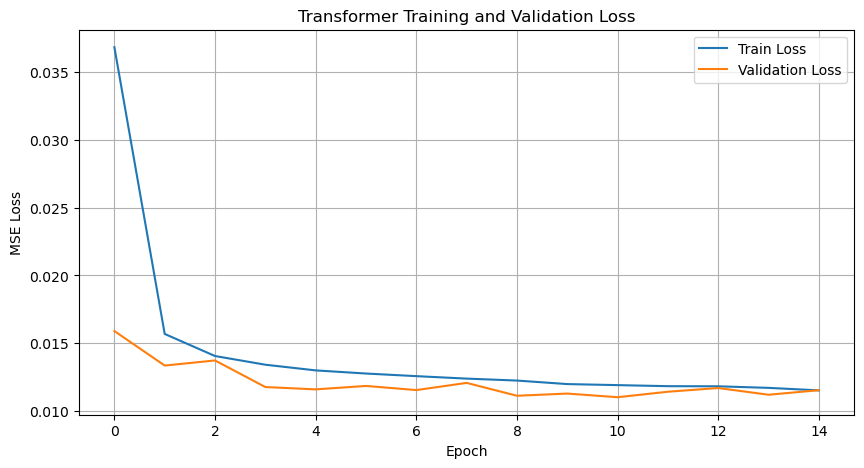

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
model.load_state_dict(torch.load("best_transformer_model.pth", map_location=device))
model.eval()

y_true_scaled = []
y_pred_scaled = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        preds = model(X_batch).cpu().numpy()

        y_pred_scaled.extend(preds)
        y_true_scaled.extend(y_batch.numpy())

y_true_scaled = np.array(y_true_scaled)
y_pred_scaled = np.array(y_pred_scaled)

# Metrics with MinMax-scaled values
mse_scaled = mean_squared_error(y_true_scaled, y_pred_scaled)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2_scaled = r2_score(y_true_scaled, y_pred_scaled)

print("Metrics WITH MinMax Scaling")
print("Scaled Test MSE:", mse_scaled)
print("Scaled Test RMSE:", rmse_scaled)
print("Scaled Test MAE:", mae_scaled)
print("Scaled Test R2:", r2_scaled)

# Metrics after inverse scaling
y_true = y_scaler.inverse_transform(y_true_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("\nMetrics AFTER Inverse Scaling")
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)
print("Test R2:", r2)

Metrics WITH MinMax Scaling
Scaled Test MSE: 0.005508914589881897
Scaled Test RMSE: 0.07422206268948538
Scaled Test MAE: 0.04060819000005722
Scaled Test R2: 0.9474114775657654

Metrics AFTER Inverse Scaling
Test MSE: 676.9068603515625
Test RMSE: 26.01743377721105
Test MAE: 14.234594345092773
Test R2: 0.9474114775657654


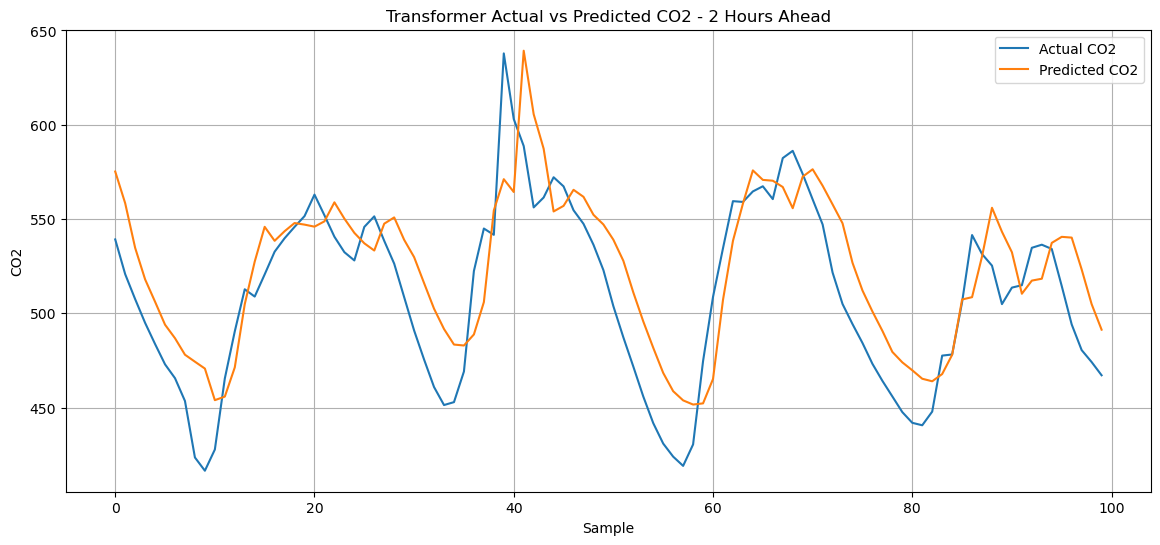

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(y_true[:100], label="Actual CO2")
plt.plot(y_pred[:100], label="Predicted CO2")
plt.xlabel("Sample")
plt.ylabel("CO2")
plt.title("Transformer Actual vs Predicted CO2 - 2 Hours Ahead")
plt.legend()
plt.grid(True)
plt.show()

## Explainability Analysis

Attention Weight Extraction Verification

In [20]:
model.eval()

num_samples = 100

sample_batch = X_test_tensor[:num_samples].to(device)

print("Sample shape:", sample_batch.shape)

with torch.no_grad():

    projected = model.input_projection(sample_batch)

    seq_len = projected.shape[1]

    projected = (
        projected +
        model.positional_encoding[:, :seq_len, :]
    )

    attention_output, attention_weights = (
        model.transformer_encoder.layers[0].self_attn(
            projected,
            projected,
            projected,
            need_weights=True,
            average_attn_weights=False
        )
    )

print("Attention output shape:")
print(attention_output.shape)

print("\nAttention weights shape:")
print(attention_weights.shape)

Sample shape: torch.Size([100, 168, 13])
Attention output shape:
torch.Size([100, 168, 32])

Attention weights shape:
torch.Size([100, 4, 168, 168])


Attention Matrix Shape: (168, 168)


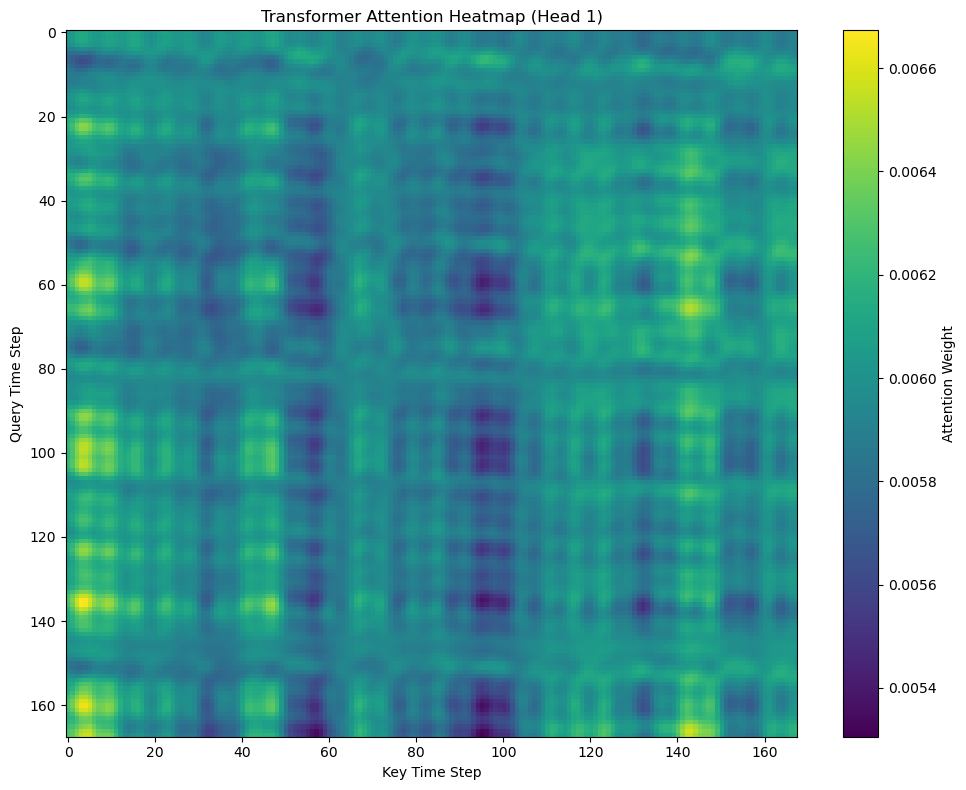

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Select first sample, first head
attention_matrix = (
    attention_weights[0, 0]
    .cpu()
    .numpy()
)

print("Attention Matrix Shape:", attention_matrix.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    attention_matrix,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Attention Weight")

plt.title(
    "Transformer Attention Heatmap (Head 1)"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

Average Attention Shape: (168, 168)


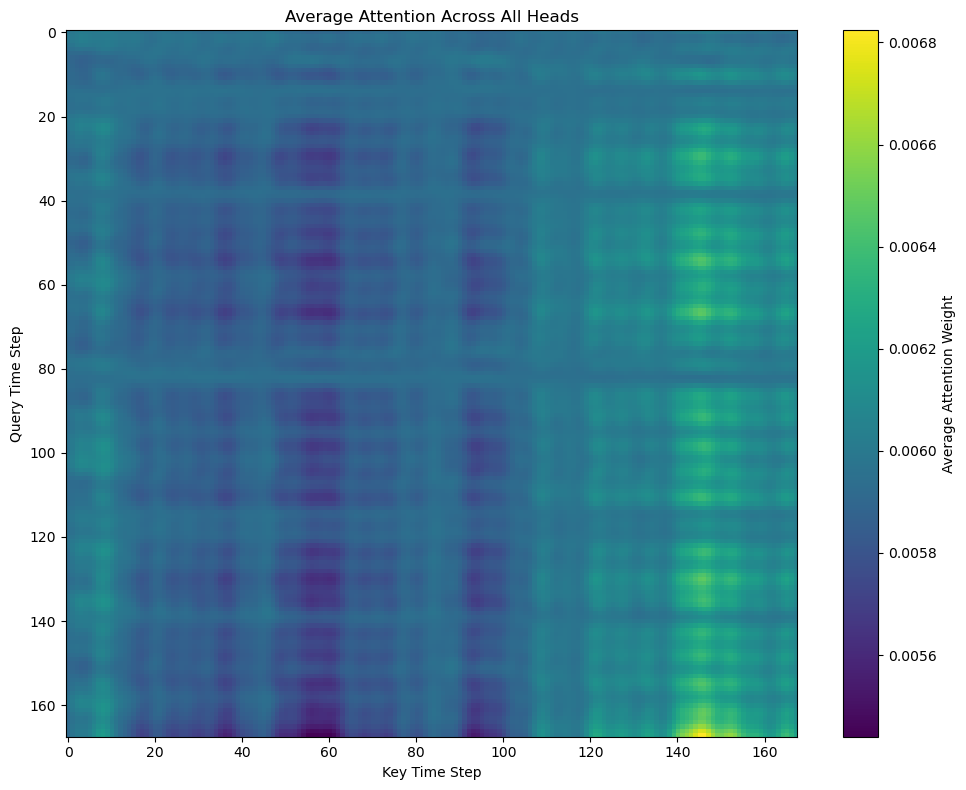

In [22]:
# Average across all 4 heads
avg_attention = (
    attention_weights
    .mean(dim=(0,1))
    .cpu()
    .numpy()
)

print("Average Attention Shape:", avg_attention.shape)

plt.figure(figsize=(10, 8))

plt.imshow(
    avg_attention,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Attention Weight")

plt.title(
    "Average Attention Across All Heads"
)

plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")

plt.tight_layout()
plt.show()

Top 10 Most Important Timesteps
Rank 1: Timestep 146 (Importance = 0.0062)
Rank 2: Timestep 145 (Importance = 0.0062)
Rank 3: Timestep 147 (Importance = 0.0062)
Rank 4: Timestep 144 (Importance = 0.0062)
Rank 5: Timestep 143 (Importance = 0.0062)
Rank 6: Timestep 148 (Importance = 0.0062)
Rank 7: Timestep 152 (Importance = 0.0062)
Rank 8: Timestep 142 (Importance = 0.0062)
Rank 9: Timestep 151 (Importance = 0.0062)
Rank 10: Timestep 153 (Importance = 0.0062)


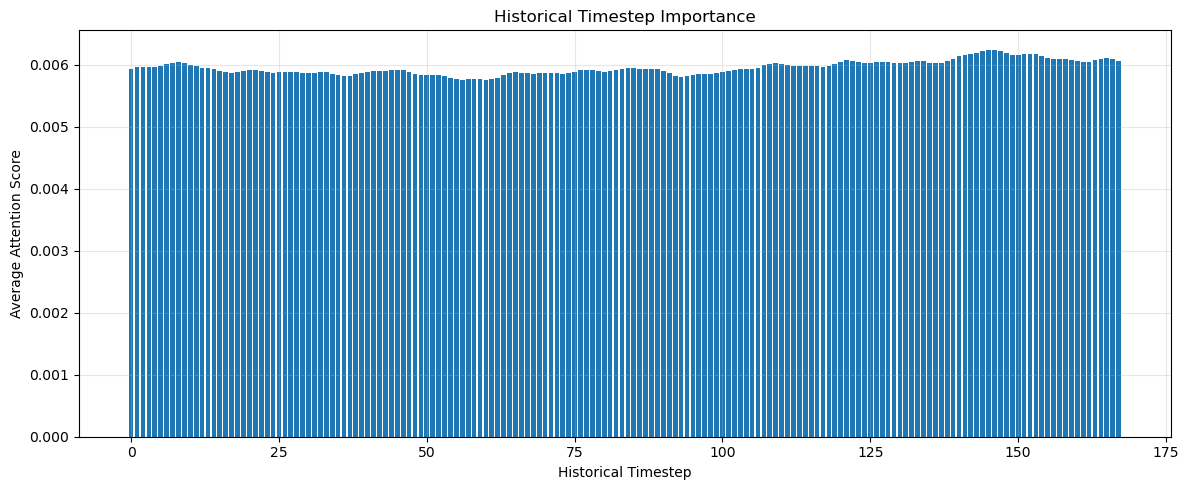

In [47]:
# Average attention over all query positions
importance_scores = avg_attention.mean(axis=0)

# Top 10 most important timesteps
top_k = 10

top_indices = np.argsort(importance_scores)[-top_k:][::-1]

print("Top 10 Most Important Timesteps")

for rank, idx in enumerate(top_indices, start=1):
    print(
        f"Rank {rank}: "
        f"Timestep {idx} "
        f"(Importance = {importance_scores[idx]:.4f})"
    )

plt.figure(figsize=(12,5))

plt.bar(
    range(len(importance_scores)),
    importance_scores
)

plt.title(
    "Historical Timestep Importance"
)

plt.xlabel("Historical Timestep")
plt.ylabel("Average Attention Score")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

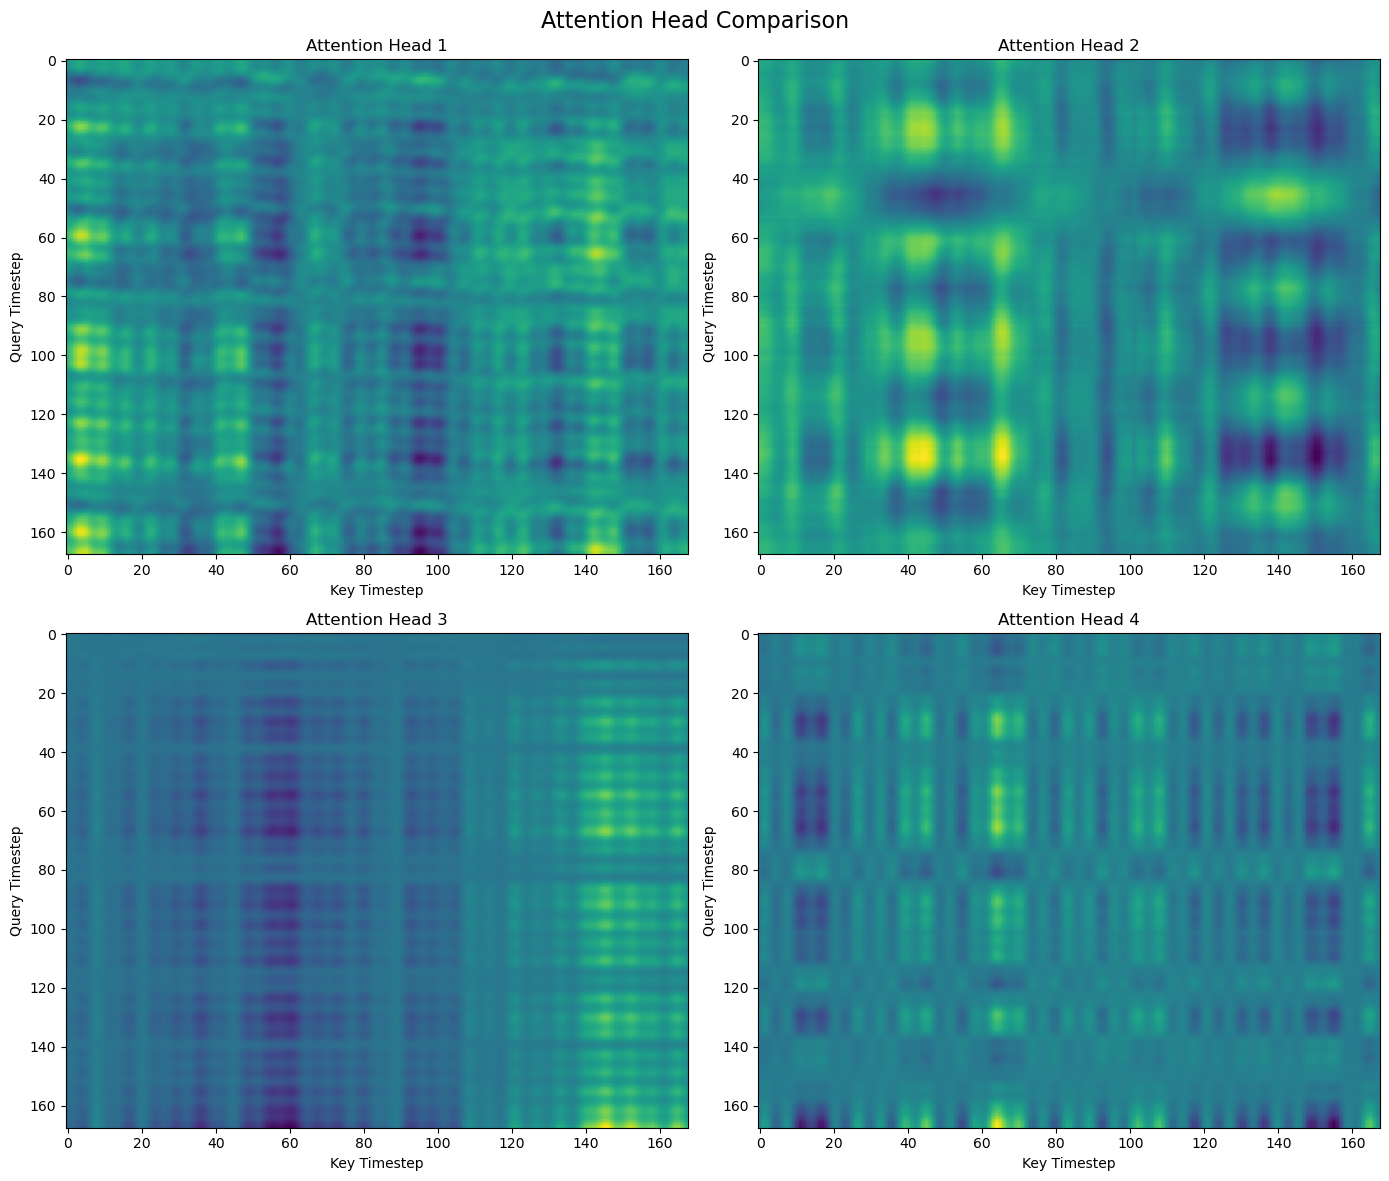

In [24]:
sample_attention = attention_weights[0]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12)
)

for head_idx, ax in enumerate(axes.flat):

    head_attention = (
        sample_attention[head_idx]
        .cpu()
        .numpy()
    )

    ax.imshow(
        head_attention,
        aspect="auto",
        cmap="viridis"
    )

    ax.set_title(
        f"Attention Head {head_idx + 1}"
    )

    ax.set_xlabel("Key Timestep")
    ax.set_ylabel("Query Timestep")

plt.suptitle(
    "Attention Head Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()

## Technique 2: Feature Ablation Analysis


Step 1 – Baseline Prediction

In [25]:
baseline_rmse = rmse
baseline_mae = mae

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)

Baseline RMSE: 26.01743377721105
Baseline MAE : 14.234594345092773


Technique 2: Feature Ablation Analysis

In [26]:


# 0. Remove old attention hook if it exists
try:
    handle.remove()
    print("Old attention hook removed.")
except:
    pass


# Step 1: Baseline Performance
baseline_rmse = rmse
baseline_mae = mae

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE :", baseline_mae)


# Step 2: Feature Selection for Ablation
ablation_features = [
    "scd41_co2",
    "scd41_temperature",
    "scd41_humidity",
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance"
]

print("\nFeatures Selected For Ablation:")
for feature in ablation_features:
    print("-", feature)

Baseline RMSE: 26.01743377721105
Baseline MAE : 14.234594345092773

Features Selected For Ablation:
- scd41_co2
- scd41_temperature
- scd41_humidity
- ens160_aqi
- ens160_tvoc
- bme688_gas_resistance


Step 3: Feature Ablation

In [27]:

ablation_results = []

model.eval()

for feature in ablation_features:
    
    feature_index = feature_cols.index(feature)
    
    X_test_ablated = X_test_tensor.clone()
    X_test_ablated[:, :, feature_index] = 0
    
    y_pred_ablated_scaled = []
    
    with torch.no_grad():
        for i in range(0, len(X_test_ablated), batch_size):
            X_batch = X_test_ablated[i:i+batch_size].to(device)
            y_batch_pred = model(X_batch)
            y_pred_ablated_scaled.append(y_batch_pred.cpu().numpy())
    
    y_pred_ablated_scaled = np.vstack(y_pred_ablated_scaled)
    y_pred_ablated = y_scaler.inverse_transform(y_pred_ablated_scaled)
    
    ablated_mse = mean_squared_error(y_true, y_pred_ablated)
    ablated_rmse = np.sqrt(ablated_mse)
    ablated_mae = mean_absolute_error(y_true, y_pred_ablated)
    
    ablation_results.append({
        "Feature": feature,
        "Ablated RMSE": ablated_rmse,
        "Ablated MAE": ablated_mae,
        "RMSE Increase": ablated_rmse - baseline_rmse,
        "MAE Increase": ablated_mae - baseline_mae
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.sort_values("RMSE Increase", ascending=False)

display(ablation_df)

,Feature,Ablated RMSE,Ablated MAE,RMSE Increase,MAE Increase
0,scd41_co2,151.588335,100.552017,125.570902,86.317423
1,scd41_temperature,27.762145,17.417311,1.744711,3.182716
3,ens160_aqi,27.034357,16.554098,1.016923,2.319504
4,ens160_tvoc,26.362706,15.153926,0.345272,0.919332
5,bme688_gas_resistance,26.311120,14.989661,0.293686,0.755067
2,scd41_humidity,26.057914,14.035295,0.040480,-0.199300


Step 4: Plot Feature Ablation Result

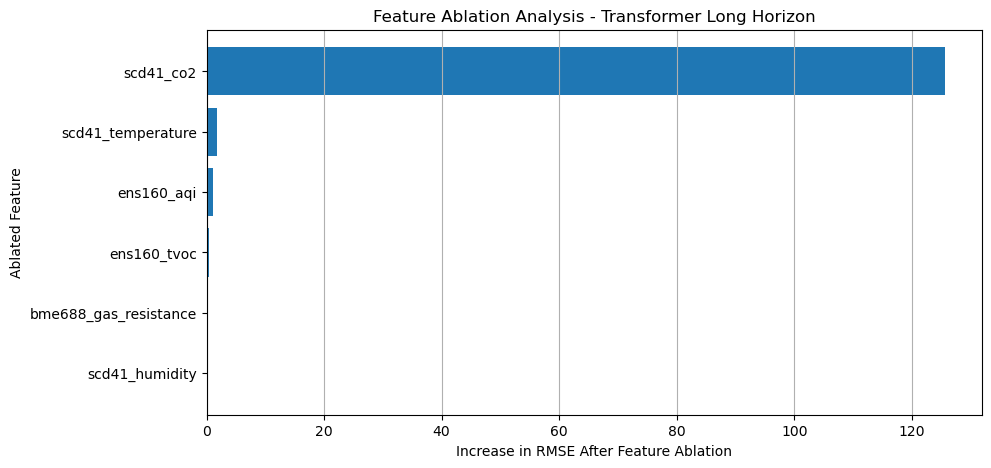

In [28]:

plt.figure(figsize=(10, 5))

plt.barh(
    ablation_df["Feature"],
    ablation_df["RMSE Increase"]
)

plt.xlabel("Increase in RMSE After Feature Ablation")
plt.ylabel("Ablated Feature")
plt.title("Feature Ablation Analysis - Transformer Long Horizon")

plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

# Uncertainty Quantification

## Technique 1: Monte Carlo Dropout


In [31]:
# ==========================================
# Monte Carlo Dropout - Step 1
# Prepare Model
# ==========================================

MC_SAMPLES = 100

# Load best model
model.load_state_dict(
    torch.load(
        "best_transformer_model.pth",
        map_location=device
    )
)

# IMPORTANT:
# Keep dropout active
model.train()

print("Monte Carlo Dropout is ready.")
print("MC Samples:", MC_SAMPLES)
print("Device:", device)

Monte Carlo Dropout is ready.
MC Samples: 100
Device: cpu


## Generate Monte Carlo Predictions

In [32]:
# ==========================================
# Monte Carlo Dropout - Step 2
# Generate MC Predictions
# ==========================================

mc_predictions = []

with torch.no_grad():

    for mc in range(MC_SAMPLES):

        batch_predictions = []

        for X_batch, _ in test_loader:

            X_batch = X_batch.to(device)

            pred = model(X_batch)

            batch_predictions.append(
                pred.cpu().numpy()
            )

        batch_predictions = np.concatenate(
            batch_predictions,
            axis=0
        )

        mc_predictions.append(batch_predictions)

mc_predictions = np.array(mc_predictions)

print("Monte Carlo Prediction Shape:")
print(mc_predictions.shape)

print("\nPrediction dtype:")
print(mc_predictions.dtype)

print("\nFirst MC prediction (first 5 values):")
print(mc_predictions[0][:5])

Monte Carlo Prediction Shape:
(100, 6169, 1)

Prediction dtype:
float32

First MC prediction (first 5 values):
[[0.5852154 ]
 [0.46338886]
 [0.40667567]
 [0.38906348]
 [0.2886784 ]]


## Step 3 – Compute Predictive Mean & Uncertainty

In [33]:
# ==========================================
# Monte Carlo Dropout - Step 3
# Predictive Mean & Uncertainty
# ==========================================

mc_mean = np.mean(
    mc_predictions,
    axis=0
)

mc_std = np.std(
    mc_predictions,
    axis=0
)

print("Mean Shape:")
print(mc_mean.shape)

print("\nStd Shape:")
print(mc_std.shape)

print("\nFirst 5 Mean Predictions:")
print(mc_mean[:5])

print("\nFirst 5 Std Values:")
print(mc_std[:5])

print("\nAverage Predictive Std:")
print(np.mean(mc_std))

Mean Shape:
(6169, 1)

Std Shape:
(6169, 1)

First 5 Mean Predictions:
[[0.5170422 ]
 [0.46426773]
 [0.39659435]
 [0.34880906]
 [0.3168215 ]]

First 5 Std Values:
[[0.03479176]
 [0.03538239]
 [0.02660892]
 [0.02260491]
 [0.02146019]]

Average Predictive Std:
0.031831343


## Step 4 – Build 95% Prediction Intervals

In [34]:
# ==========================================
# Monte Carlo Dropout - Step 4
# 95% Prediction Intervals
# ==========================================

z_score = 1.96

lower_bound = mc_mean - z_score * mc_std
upper_bound = mc_mean + z_score * mc_std

print("Lower Bound Shape:")
print(lower_bound.shape)

print("\nUpper Bound Shape:")
print(upper_bound.shape)

print("\nFirst 5 Lower Bounds:")
print(lower_bound[:5])

print("\nFirst 5 Upper Bounds:")
print(upper_bound[:5])

Lower Bound Shape:
(6169, 1)

Upper Bound Shape:
(6169, 1)

First 5 Lower Bounds:
[[0.44885036]
 [0.39491826]
 [0.34444085]
 [0.30450344]
 [0.27475953]]

First 5 Upper Bounds:
[[0.58523405]
 [0.5336172 ]
 [0.44874784]
 [0.3931147 ]
 [0.35888344]]


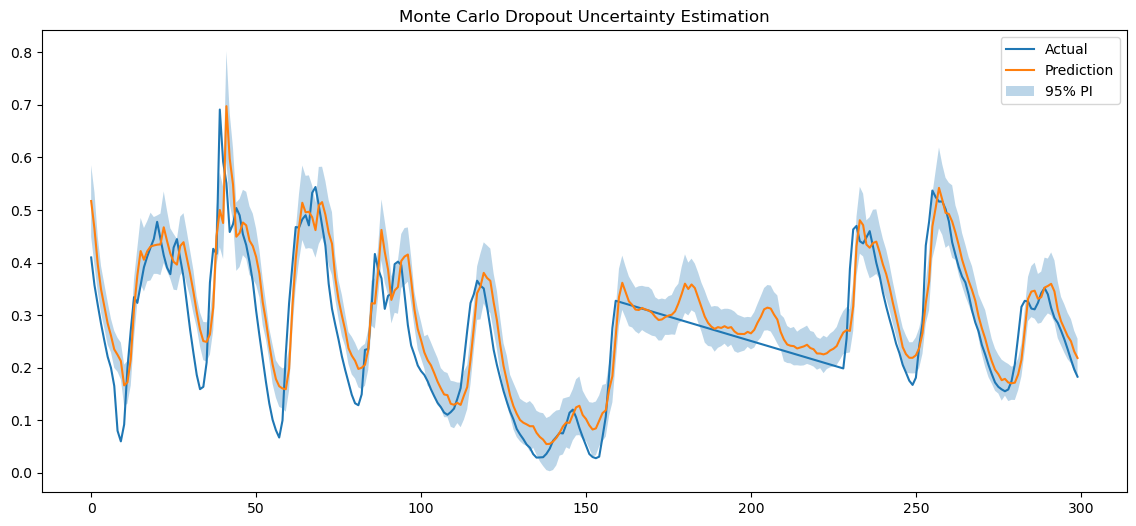

In [43]:
plt.figure(figsize=(14,6))

n = 300

plt.plot(
    y_true[:n],
    label="Actual"
)

plt.plot(
    mc_mean[:n],
    label="Prediction"
)

plt.fill_between(
    np.arange(n),
    lower_bound[:n].flatten(),
    upper_bound[:n].flatten(),
    alpha=0.3,
    label="95% PI"
)

plt.legend()
plt.title("Monte Carlo Dropout Uncertainty Estimation")
plt.show()

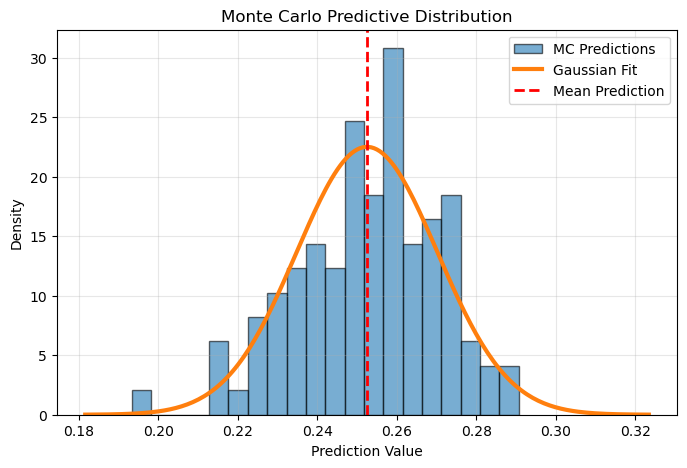

In [45]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

sample_idx = 100

sample_predictions = mc_predictions[:, sample_idx, 0]

mean_prediction = np.mean(sample_predictions)
std_prediction = np.std(sample_predictions)

x = np.linspace(
    mean_prediction - 4 * std_prediction,
    mean_prediction + 4 * std_prediction,
    200
)

plt.figure(figsize=(8,5))

plt.hist(
    sample_predictions,
    bins=20,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='MC Predictions'
)

plt.plot(
    x,
    norm.pdf(x, mean_prediction, std_prediction),
    linewidth=3,
    label='Gaussian Fit'
)

plt.axvline(
    mean_prediction,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mean Prediction'
)

plt.title("Monte Carlo Predictive Distribution")
plt.xlabel("Prediction Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## TEQ 2 Prediction Interval Evaluation


 Coverage Evaluation on FULL Test Set

In [35]:
# ==========================================
# Monte Carlo Dropout - Step 5
# Coverage on Full Test Set
# ==========================================

y_true = y_test_tensor.cpu().numpy()

coverage = np.mean(
    (y_true >= lower_bound) &
    (y_true <= upper_bound)
)

print("Coverage Probability:")
print(f"{coverage*100:.2f}%")

Coverage Probability:
72.90%


In [36]:
mpiw = np.mean(upper_bound - lower_bound)

print("Mean Prediction Interval Width (MPIW):")
print(mpiw)

Mean Prediction Interval Width (MPIW):
0.124778874
